# Manhattan Terrain Features

This notebook derives terrain characteristics from the cleaned 5 m
Manhattan digital elevation model.

## Objectives

- Calculate terrain slope from the final DEM
- Identify low-lying terrain
- Develop hydrologically relevant terrain indicators
- Summarize terrain characteristics at the building level
- Prepare terrain predictors for the pluvial flood-risk model

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show


# Make the notebook work whether it is launched from the repository root
# or from the notebooks folder.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

DEM_PATH = (
    PROCESSED_DIR
    / "manhattan_dem_5m_final_navd88_m_epsg6539.tif"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("Project root:", PROJECT_ROOT)
print("Final DEM:", DEM_PATH)
print("DEM exists:", DEM_PATH.exists())

print("\nAvailable processed GeoPackage files:")
for path in sorted(PROCESSED_DIR.glob("*.gpkg")):
    print("-", path.name)

Project root: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk
Final DEM: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\processed\manhattan_dem_5m_final_navd88_m_epsg6539.tif
DEM exists: True

Available processed GeoPackage files:
- manhattan_building_footprints_processed.gpkg
- manhattan_buildings_with_terrain.gpkg


In [2]:
US_SURVEY_FOOT_TO_METER = 1200 / 3937

with rasterio.open(DEM_PATH) as source:
    dem = source.read(1, masked=True).astype(np.float32)

    dem_profile = source.profile.copy()
    dem_transform = source.transform
    dem_crs = source.crs
    dem_bounds = source.bounds
    dem_nodata = source.nodata

    pixel_width_ft = abs(source.res[0])
    pixel_height_ft = abs(source.res[1])


pixel_width_m = pixel_width_ft * US_SURVEY_FOOT_TO_METER
pixel_height_m = pixel_height_ft * US_SURVEY_FOOT_TO_METER

valid_elevations = dem.compressed()

print("CRS:", dem_crs)
print("DEM shape:", dem.shape)
print("Horizontal resolution (ft):", pixel_width_ft, pixel_height_ft)
print(
    "Horizontal resolution (m):",
    round(pixel_width_m, 4),
    round(pixel_height_m, 4),
)
print("NoData value:", dem_nodata)
print("Valid pixels:", valid_elevations.size)
print(
    "Elevation range:",
    round(float(valid_elevations.min()), 2),
    "to",
    round(float(valid_elevations.max()), 2),
    "m NAVD88",
)

CRS: EPSG:6539
DEM shape: (4412, 2178)
Horizontal resolution (ft): 16.40416666666667 16.40416666666667
Horizontal resolution (m): 5.0 5.0
NoData value: -9999.0
Valid pixels: 2766408
Elevation range: -10.68 to 81.03 m NAVD88


The terrain slope is calculated from the elevation gradients in the
horizontal \(x\) and \(y\) directions:

$$
\text{Slope}
=
\arctan\left(
\sqrt{
\left(\frac{\partial z}{\partial x}\right)^2
+
\left(\frac{\partial z}{\partial y}\right)^2
}
\right)
$$

where:

- \(z\) is terrain elevation;
- \(\frac{\partial z}{\partial x}\) is the east–west elevation gradient;
- \(\frac{\partial z}{\partial y}\) is the north–south elevation gradient.

The elevation gradients are estimated using the Horn \(3 \times 3\)
method, consistent with the standard approach used by GDAL/QGIS.
Horizontal and vertical measurements are converted to metres before
calculating slope.

Using the Horn \(3 \times 3\) neighborhood,

$$
\frac{\partial z}{\partial x}
=
\frac{(z_3 + 2z_6 + z_9) - (z_1 + 2z_4 + z_7)}
{8\Delta x}
$$

$$
\frac{\partial z}{\partial y}
=
\frac{(z_7 + 2z_8 + z_9) - (z_1 + 2z_2 + z_3)}
{8\Delta y}
$$

where \(\Delta x\) and \(\Delta y\) are the horizontal pixel dimensions
in metres. Pixels without a complete valid \(3 \times 3\) neighborhood
are treated as NoData.

In [3]:
dem_values = dem.filled(np.nan).astype(np.float64)

# Horn 3 × 3 neighborhood
z1 = dem_values[:-2, :-2]
z2 = dem_values[:-2, 1:-1]
z3 = dem_values[:-2, 2:]

z4 = dem_values[1:-1, :-2]
z5 = dem_values[1:-1, 1:-1]
z6 = dem_values[1:-1, 2:]

z7 = dem_values[2:, :-2]
z8 = dem_values[2:, 1:-1]
z9 = dem_values[2:, 2:]


with np.errstate(invalid="ignore", divide="ignore"):
    elevation_change_x = (
        (z3 + 2 * z6 + z9)
        - (z1 + 2 * z4 + z7)
    ) / (8 * pixel_width_m)

    elevation_change_y = (
        (z7 + 2 * z8 + z9)
        - (z1 + 2 * z2 + z3)
    ) / (8 * pixel_height_m)

    gradient_magnitude = np.hypot(
        elevation_change_x,
        elevation_change_y,
    )

    interior_slope_degrees = np.degrees(
        np.arctan(gradient_magnitude)
    )

    interior_slope_percent = gradient_magnitude * 100


# Restore the original raster dimensions
slope_degrees_values = np.full(
    dem_values.shape,
    np.nan,
    dtype=np.float32,
)

slope_percent_values = np.full(
    dem_values.shape,
    np.nan,
    dtype=np.float32,
)

slope_degrees_values[1:-1, 1:-1] = interior_slope_degrees
slope_percent_values[1:-1, 1:-1] = interior_slope_percent


slope_degrees = np.ma.masked_invalid(slope_degrees_values)
slope_percent = np.ma.masked_invalid(slope_percent_values)

valid_slope = slope_degrees.compressed()

print("Method: Horn 3 x 3")
print("Valid slope pixels:", valid_slope.size)
print("Minimum slope:", round(float(valid_slope.min()), 2), "degrees")
print("Median slope:", round(float(np.median(valid_slope)), 2), "degrees")
print(
    "95th percentile:",
    round(float(np.percentile(valid_slope, 95)), 2),
    "degrees",
)
print("Maximum slope:", round(float(valid_slope.max()), 2), "degrees")

Method: Horn 3 x 3
Valid slope pixels: 2743529
Minimum slope: 0.0 degrees
Median slope: 1.57 degrees
95th percentile: 13.51 degrees
Maximum slope: 70.49 degrees


## Terrain Slope

Slope is calculated in degrees using the Horn \(3 \times 3\) method.
Higher slope values indicate more rapid changes in terrain elevation.

For visualization, the color scale is capped at the 99th percentile so
that a small number of extreme shoreline or infrastructure-edge values
do not obscure terrain variation across most of Manhattan.

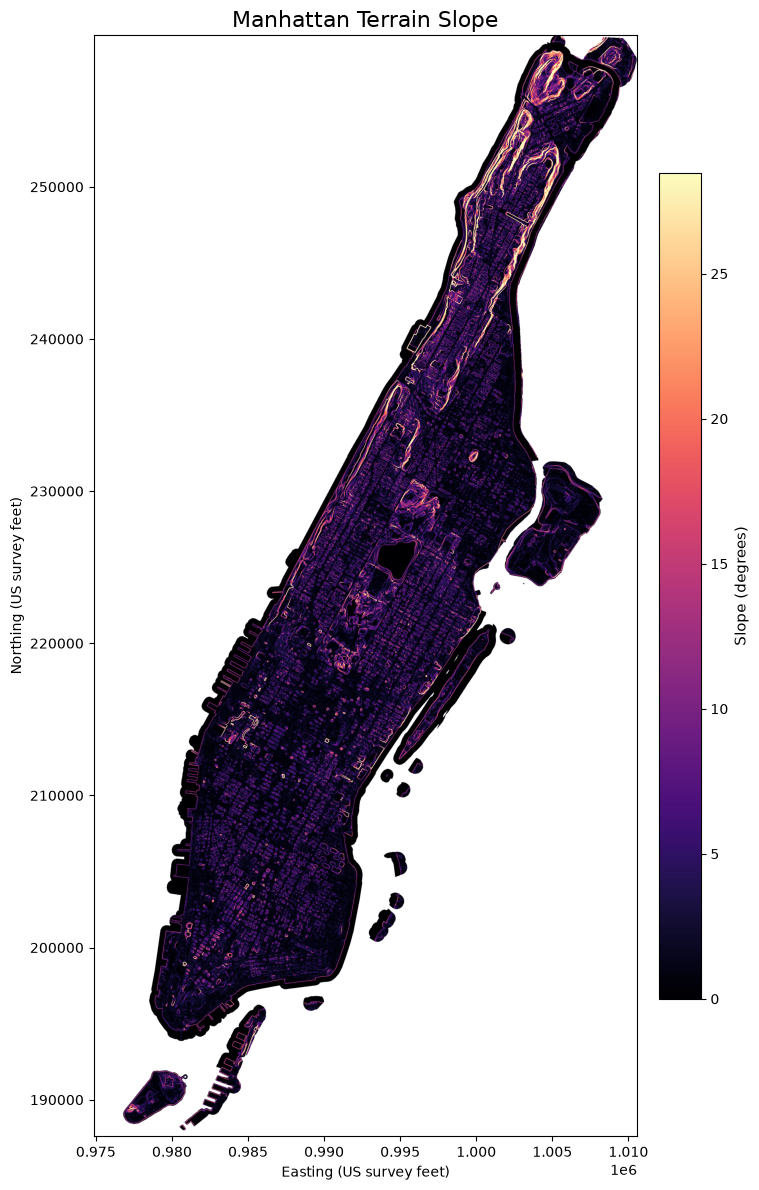

Display maximum: 28.47 degrees
Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\outputs\manhattan_terrain_slope.png


In [4]:
slope_display_max = float(
    np.percentile(valid_slope, 99)
)

slope_cmap = plt.colormaps["magma"].copy()
slope_cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(8, 12))

image = ax.imshow(
    slope_degrees,
    cmap=slope_cmap,
    vmin=0,
    vmax=slope_display_max,
    extent=(
        dem_bounds.left,
        dem_bounds.right,
        dem_bounds.bottom,
        dem_bounds.top,
    ),
    origin="upper",
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.75,
    pad=0.03,
)

colorbar.set_label(
    "Slope (degrees)",
    fontsize=11,
)

ax.set_title(
    "Manhattan Terrain Slope",
    fontsize=16,
)

ax.set_xlabel("Easting (US survey feet)")
ax.set_ylabel("Northing (US survey feet)")
ax.set_aspect("equal")

plt.tight_layout()

slope_figure_path = (
    OUTPUT_DIR
    / "manhattan_terrain_slope.png"
)

fig.savefig(
    slope_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Display maximum:", round(slope_display_max, 2), "degrees")
print("Saved to:", slope_figure_path)

In [5]:
SLOPE_PATH = (
    PROCESSED_DIR
    / "manhattan_slope_degrees_5m_epsg6539.tif"
)

slope_nodata = -9999.0

slope_profile = dem_profile.copy()

slope_profile.update(
    driver="GTiff",
    dtype="float32",
    count=1,
    nodata=slope_nodata,
    compress="deflate",
    predictor=3,
    tiled=True,
    BIGTIFF="IF_SAFER",
)

with rasterio.open(
    SLOPE_PATH,
    "w",
    **slope_profile,
) as destination:
    destination.write(
        slope_degrees.filled(slope_nodata).astype(np.float32),
        1,
    )

    destination.update_tags(
        terrain_variable="slope",
        units="degrees",
        method="Horn 3x3",
        source_dem=DEM_PATH.name,
        horizontal_resolution_m=round(pixel_width_m, 4),
    )


with rasterio.open(SLOPE_PATH) as check:
    saved_slope = check.read(1, masked=True)

    print("Saved to:", SLOPE_PATH)
    print("CRS:", check.crs)
    print("Shape:", saved_slope.shape)
    print("Resolution:", check.res)
    print("NoData:", check.nodata)
    print(
        "File size:",
        round(SLOPE_PATH.stat().st_size / 1024**2, 2),
        "MB",
    )

Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\processed\manhattan_slope_degrees_5m_epsg6539.tif
CRS: EPSG:6539
Shape: (4412, 2178)
Resolution: (16.40416666666667, 16.40416666666667)
NoData: -9999.0
File size: 8.49 MB


## Building-Level Terrain Attributes

Terrain variables will be assigned to each Manhattan building using a
representative point located inside its footprint.

Representative points are used instead of geometric centroids because a
centroid can fall outside an irregular or multipart building polygon.
All building geometries are transformed to the DEM coordinate reference
system before raster values are sampled.

In [6]:
BUILDINGS_PATH = (
    PROCESSED_DIR
    / "manhattan_building_footprints_processed.gpkg"
)

if not BUILDINGS_PATH.exists():
    raise FileNotFoundError(
        "Processed Manhattan building footprints were not found: "
        f"{BUILDINGS_PATH}"
    )


buildings = gpd.read_file(
    BUILDINGS_PATH
)

original_building_crs = buildings.crs

buildings_dem_crs = buildings.to_crs(
    dem_crs
)


print("Selected file:", BUILDINGS_PATH.name)
print("Number of buildings:", len(buildings))
print("Original CRS:", original_building_crs)
print("DEM CRS:", buildings_dem_crs.crs)

print(
    "Geometry types:",
    buildings_dem_crs.geometry
    .geom_type
    .value_counts()
    .to_dict(),
)

Selected file: manhattan_building_footprints_processed.gpkg
Number of buildings: 45195
Original CRS: EPSG:2263
DEM CRS: PROJCS["NAD83(2011) / New York Long Island (ftUS)",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6318"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",40.1666666666667],PARAMETER["central_meridian",-74],PARAMETER["standard_parallel_1",41.0333333333333],PARAMETER["standard_parallel_2",40.6666666666667],PARAMETER["false_easting",984250],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","6539"]]
Geometry types: {'MultiPolygon': 45195}


In [7]:
building_points = (
    buildings_dem_crs.geometry
    .representative_point()
)

point_x = building_points.x.to_numpy()
point_y = building_points.y.to_numpy()

sample_rows, sample_columns = rasterio.transform.rowcol(
    dem_transform,
    point_x,
    point_y,
)

sample_rows = np.asarray(sample_rows, dtype=int)
sample_columns = np.asarray(sample_columns, dtype=int)


inside_raster = (
    (sample_rows >= 0)
    & (sample_rows < dem.shape[0])
    & (sample_columns >= 0)
    & (sample_columns < dem.shape[1])
)

building_elevation_m = np.full(
    len(buildings_dem_crs),
    np.nan,
    dtype=np.float32,
)

building_slope_degrees = np.full(
    len(buildings_dem_crs),
    np.nan,
    dtype=np.float32,
)


valid_indices = np.where(inside_raster)[0]

building_elevation_m[valid_indices] = (
    dem[
        sample_rows[valid_indices],
        sample_columns[valid_indices],
    ]
    .filled(np.nan)
    .astype(np.float32)
)

building_slope_degrees[valid_indices] = (
    slope_degrees[
        sample_rows[valid_indices],
        sample_columns[valid_indices],
    ]
    .filled(np.nan)
    .astype(np.float32)
)


buildings_terrain = buildings_dem_crs.copy()

buildings_terrain["dem_elevation_m"] = building_elevation_m
buildings_terrain["slope_degrees"] = building_slope_degrees


elevation_available = np.isfinite(
    buildings_terrain["dem_elevation_m"]
)

slope_available = np.isfinite(
    buildings_terrain["slope_degrees"]
)

both_available = elevation_available & slope_available


print("Total buildings:", len(buildings_terrain))
print("Buildings inside raster bounds:", inside_raster.sum())
print("Buildings with DEM elevation:", elevation_available.sum())
print("Buildings with slope:", slope_available.sum())
print("Buildings with both:", both_available.sum())

print(
    "Combined terrain coverage:",
    f"{both_available.mean():.2%}",
)

Total buildings: 45195
Buildings inside raster bounds: 45172
Buildings with DEM elevation: 45169
Buildings with slope: 45169
Buildings with both: 45169
Combined terrain coverage: 99.94%


In [8]:
terrain_summary = (
    buildings_terrain.loc[
        both_available,
        [
            "dem_elevation_m",
            "slope_degrees",
        ],
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .round(2)
)

terrain_summary

,dem_elevation_m,slope_degrees
count,45169.00,45169.00
mean,14.44,4.19
std,11.98,3.57
min,-10.46,0.00
1%,1.87,0.18
5%,3.06,0.46
25%,6.37,1.47
50%,10.21,3.28
75%,19.28,6.04
95%,37.89,10.53


In [9]:
buildings_terrain["terrain_model_eligible"] = both_available

buildings_terrain["terrain_exclusion_reason"] = pd.Series(
    pd.NA,
    index=buildings_terrain.index,
    dtype="string",
)

outside_mask = ~inside_raster

missing_elevation_mask = (
    inside_raster
    & ~elevation_available
)

missing_slope_mask = (
    elevation_available
    & ~slope_available
)


buildings_terrain.loc[
    outside_mask,
    "terrain_exclusion_reason",
] = "Outside final DEM bounds"

buildings_terrain.loc[
    missing_elevation_mask,
    "terrain_exclusion_reason",
] = "No valid DEM elevation"

buildings_terrain.loc[
    missing_slope_mask,
    "terrain_exclusion_reason",
] = "No valid Horn slope neighborhood"


print(
    buildings_terrain["terrain_model_eligible"]
    .value_counts(dropna=False)
)

print("\nExclusion reasons:")
print(
    buildings_terrain.loc[
        ~buildings_terrain["terrain_model_eligible"],
        "terrain_exclusion_reason",
    ]
    .value_counts(dropna=False)
)

terrain_model_eligible
True     45169
False       26
Name: count, dtype: int64

Exclusion reasons:
terrain_exclusion_reason
Outside final DEM bounds    23
No valid DEM elevation       3
Name: count, dtype: Int64


In [10]:
from pysheds.grid import Grid

## Hydrologic Terrain Processing

Surface-flow indicators are derived from the final 5 m DEM using the
D8 flow-routing method.

The workflow includes:

1. filling isolated pits;
2. filling depressions for continuous flow routing;
3. resolving flat terrain;
4. calculating D8 flow direction;
5. calculating upstream flow accumulation.

The hydrologically corrected DEM is used only for flow routing. The
original DEM is preserved, and the difference between the filled and
original elevations is retained as a separate depression-depth
indicator.

Flow accumulation represents potential surface-runoff concentration. It
does not include storm-sewer capacity and should not be interpreted as
observed flood depth.

In [11]:
grid = Grid.from_raster(
    str(DEM_PATH)
)

hydro_dem = grid.read_raster(
    str(DEM_PATH)
)

hydro_dem_values = np.asarray(
    hydro_dem,
    dtype=np.float64,
)

hydro_nodata = hydro_dem.nodata

if hydro_nodata is None or np.isnan(hydro_nodata):
    hydro_valid = np.isfinite(hydro_dem_values)
else:
    hydro_valid = (
        np.isfinite(hydro_dem_values)
        & (hydro_dem_values != hydro_nodata)
    )


print("PySheds DEM shape:", hydro_dem.shape)
print("PySheds NoData:", hydro_nodata)
print("Valid pixels:", hydro_valid.sum())
print(
    "Elevation range:",
    round(float(hydro_dem_values[hydro_valid].min()), 2),
    "to",
    round(float(hydro_dem_values[hydro_valid].max()), 2),
    "m NAVD88",
)

PySheds DEM shape: (4412, 2178)
PySheds NoData: -9999.0
Valid pixels: 2766408
Elevation range: -10.68 to 81.03 m NAVD88


### Depression Filling and Flat Resolution

A D8 flow-routing algorithm requires each valid cell to have a defined
downslope path.

- Isolated pits are single cells lower than all adjacent cells.
- Depressions are larger enclosed areas without a lower outlet.
- Flats are areas where neighboring cells have equal elevation, so the
  downslope direction is ambiguous.

Pits and depressions are filled only in a temporary routing DEM. The
original terrain elevations remain unchanged. Depression depth is
retained separately because enclosed low areas may indicate potential
surface-water ponding.

In [12]:
from time import perf_counter

hydrology_start = perf_counter()

# Fill isolated single-cell pits.
pit_filled_dem = grid.fill_pits(
    hydro_dem
)

# Fill larger enclosed depressions.
depression_filled_dem = grid.fill_depressions(
    pit_filled_dem
)

# Add a very small artificial gradient across flat areas so that
# every routed cell can receive a D8 flow direction.
routing_dem = grid.resolve_flats(
    depression_filled_dem
)

hydrology_seconds = (
    perf_counter() - hydrology_start
)


depression_filled_values = np.asarray(
    depression_filled_dem,
    dtype=np.float64,
)

depression_depth_m = np.full(
    hydro_dem_values.shape,
    np.nan,
    dtype=np.float32,
)

raw_depression_depth = (
    depression_filled_values
    - hydro_dem_values
)

# Remove negligible floating-point differences and prevent negative depth.
raw_depression_depth[
    np.abs(raw_depression_depth) < 1e-6
] = 0

depression_depth_m[hydro_valid] = np.maximum(
    raw_depression_depth[hydro_valid],
    0,
).astype(np.float32)


positive_depression_depth = depression_depth_m[
    np.isfinite(depression_depth_m)
    & (depression_depth_m > 0.01)
]


print(
    "Hydrologic conditioning time:",
    round(hydrology_seconds, 2),
    "seconds",
)

print(
    "Pixels with depression depth > 0.01 m:",
    positive_depression_depth.size,
)

print(
    "Share of valid pixels:",
    f"{positive_depression_depth.size / hydro_valid.sum():.2%}",
)

if positive_depression_depth.size:
    print(
        "Median positive depth:",
        round(
            float(np.median(positive_depression_depth)),
            3,
        ),
        "m",
    )

    print(
        "95th percentile positive depth:",
        round(
            float(
                np.percentile(
                    positive_depression_depth,
                    95,
                )
            ),
            3,
        ),
        "m",
    )

    print(
        "Maximum depression depth:",
        round(
            float(positive_depression_depth.max()),
            3,
        ),
        "m",
    )

Hydrologic conditioning time: 5.85 seconds
Pixels with depression depth > 0.01 m: 460512
Share of valid pixels: 16.65%
Median positive depth: 0.504 m
95th percentile positive depth: 2.757 m
Maximum depression depth: 16.176 m


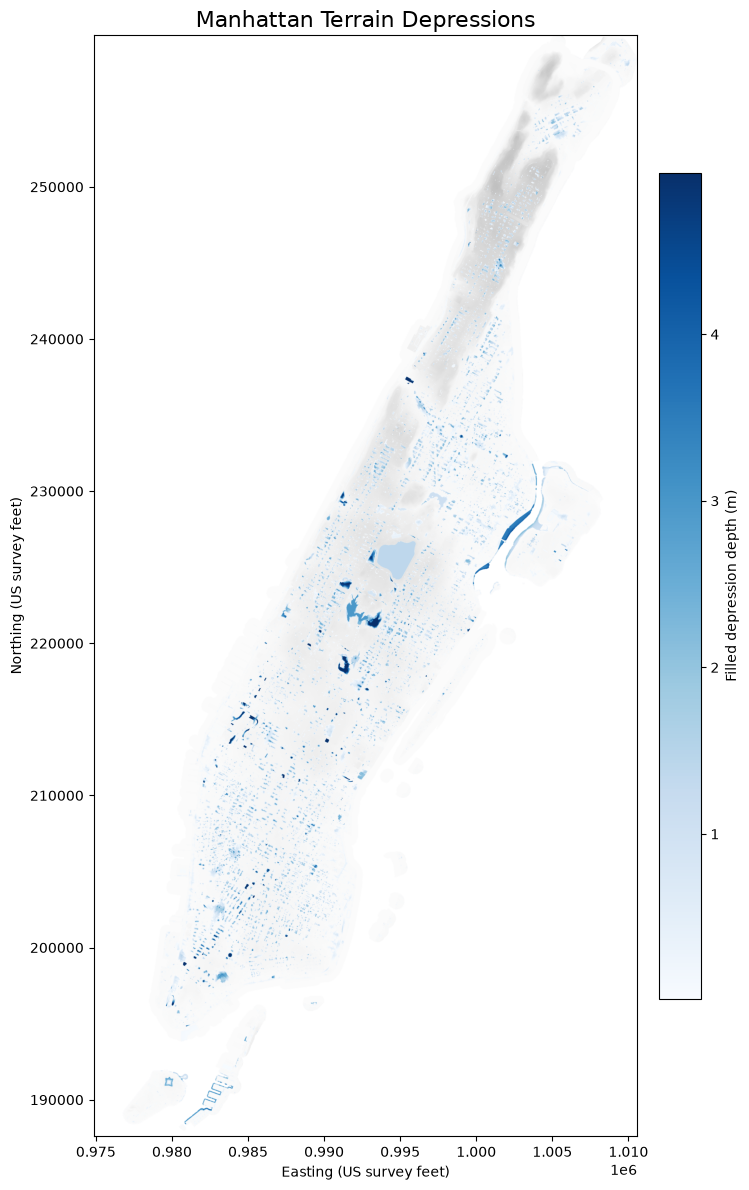

Display capped at: 4.968 m
Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\outputs\manhattan_depression_depth.png


In [13]:
depression_display_max = float(
    np.percentile(
        positive_depression_depth,
        99,
    )
)

depression_display = np.ma.masked_where(
    ~np.isfinite(depression_depth_m)
    | (depression_depth_m <= 0.01),
    depression_depth_m,
)

depression_cmap = plt.colormaps["Blues"].copy()
depression_cmap.set_bad(alpha=0)

fig, ax = plt.subplots(figsize=(8, 12))

# Subtle elevation background for geographic context.
ax.imshow(
    dem,
    cmap="Greys",
    extent=(
        dem_bounds.left,
        dem_bounds.right,
        dem_bounds.bottom,
        dem_bounds.top,
    ),
    origin="upper",
    alpha=0.25,
)

depression_image = ax.imshow(
    depression_display,
    cmap=depression_cmap,
    vmin=0.01,
    vmax=depression_display_max,
    extent=(
        dem_bounds.left,
        dem_bounds.right,
        dem_bounds.bottom,
        dem_bounds.top,
    ),
    origin="upper",
)

colorbar = fig.colorbar(
    depression_image,
    ax=ax,
    shrink=0.75,
    pad=0.03,
)

colorbar.set_label(
    "Filled depression depth (m)",
)

ax.set_title(
    "Manhattan Terrain Depressions",
    fontsize=16,
)

ax.set_xlabel("Easting (US survey feet)")
ax.set_ylabel("Northing (US survey feet)")
ax.set_aspect("equal")

plt.tight_layout()

depression_figure_path = (
    OUTPUT_DIR
    / "manhattan_depression_depth.png"
)

fig.savefig(
    depression_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Display capped at:",
    round(depression_display_max, 3),
    "m",
)
print("Saved to:", depression_figure_path)

### D8 Flow Direction and Accumulation

The D8 method routes each raster cell toward one of its eight adjacent
neighbors using the direction of steepest descent.

Flow accumulation counts the number of upstream cells that drain
through each cell. Larger values indicate greater potential
concentration of surface runoff.

Because flow accumulation is strongly right-skewed, a logarithmic
transformation will later be used for visualization and statistical
modeling.

In [14]:
# Compatibility fix
if not hasattr(np, "in1d"):
    setattr(np, "in1d", np.isin)


D8_DIRECTION_MAP = (
    64,   # North
    128,  # Northeast
    1,    # East
    2,    # Southeast
    4,    # South
    8,    # Southwest
    16,   # West
    32,   # Northwest
)

flow_start = perf_counter()

flow_direction = grid.flowdir(
    routing_dem,
    routing="d8",
    dirmap=D8_DIRECTION_MAP,
)

flow_accumulation = grid.accumulation(
    flow_direction,
    routing="d8",
    dirmap=D8_DIRECTION_MAP,
)

flow_seconds = perf_counter() - flow_start


flow_accumulation_raw = np.asarray(
    flow_accumulation,
    dtype=np.float64,
)

flow_accumulation_cells = np.full(
    hydro_dem_values.shape,
    np.nan,
    dtype=np.float64,
)

flow_accumulation_cells[hydro_valid] = (
    flow_accumulation_raw[hydro_valid]
)

valid_flow_accumulation = flow_accumulation_cells[
    np.isfinite(flow_accumulation_cells)
    & (flow_accumulation_cells >= 0)
]

pixel_area_m2 = (
    pixel_width_m
    * pixel_height_m
)

maximum_upstream_area_km2 = (
    valid_flow_accumulation.max()
    * pixel_area_m2
    / 1_000_000
)


print(
    "D8 calculation time:",
    round(flow_seconds, 2),
    "seconds",
)

print(
    "Valid accumulation pixels:",
    valid_flow_accumulation.size,
)

print(
    "Minimum accumulation:",
    round(float(valid_flow_accumulation.min()), 2),
    "cells",
)

print(
    "Median accumulation:",
    round(float(np.median(valid_flow_accumulation)), 2),
    "cells",
)

print(
    "95th percentile:",
    round(
        float(
            np.percentile(
                valid_flow_accumulation,
                95,
            )
        ),
        2,
    ),
    "cells",
)

print(
    "99th percentile:",
    round(
        float(
            np.percentile(
                valid_flow_accumulation,
                99,
            )
        ),
        2,
    ),
    "cells",
)

print(
    "Maximum accumulation:",
    round(float(valid_flow_accumulation.max()), 2),
    "cells",
)

print(
    "Maximum upstream area:",
    round(maximum_upstream_area_km2, 3),
    "km²",
)

D8 calculation time: 0.43 seconds
Valid accumulation pixels: 2766408
Minimum accumulation: 1.0 cells
Median accumulation: 2.0 cells
95th percentile: 171.0 cells
99th percentile: 2966.0 cells
Maximum accumulation: 213621.0 cells
Maximum upstream area: 5.341 km²


### D8 Flow Accumulation

The D8 method routes surface flow from each raster cell toward one of
its eight adjacent cells using the direction of steepest descent.

Flow accumulation for a cell is defined as the number of upstream cells
that drain through that location:

$$
A_i = \sum_{j \in U_i} 1
$$

where:

- \(A_i\) is the flow accumulation at cell \(i\);
- \(U_i\) is the set of upstream cells draining through cell \(i\).

Because the DEM has a spatial resolution of approximately
\(5 \times 5\) metres, upstream contributing area can be estimated as:

$$
\text{Upstream area}_i
=
A_i \times 25\text{ m}^2
$$

Flow-accumulation values are strongly right-skewed. Most cells receive
flow from only a small area, while a limited number of drainage paths
receive flow from thousands of upstream cells. A base-10 logarithmic
transformation is therefore used for visualization:

$$
A_i^{*}
=
\log_{10}(A_i)
$$

For map clarity, cells with fewer than 10 upstream cells are hidden and
the color scale is capped at the 99.9th percentile. These display
choices do not modify the original flow-accumulation values used in the
analysis.

Flow accumulation represents potential surface-runoff concentration.
It does not account for rainfall intensity, infiltration, storm-sewer
capacity, drainage infrastructure, or observed flood depth.

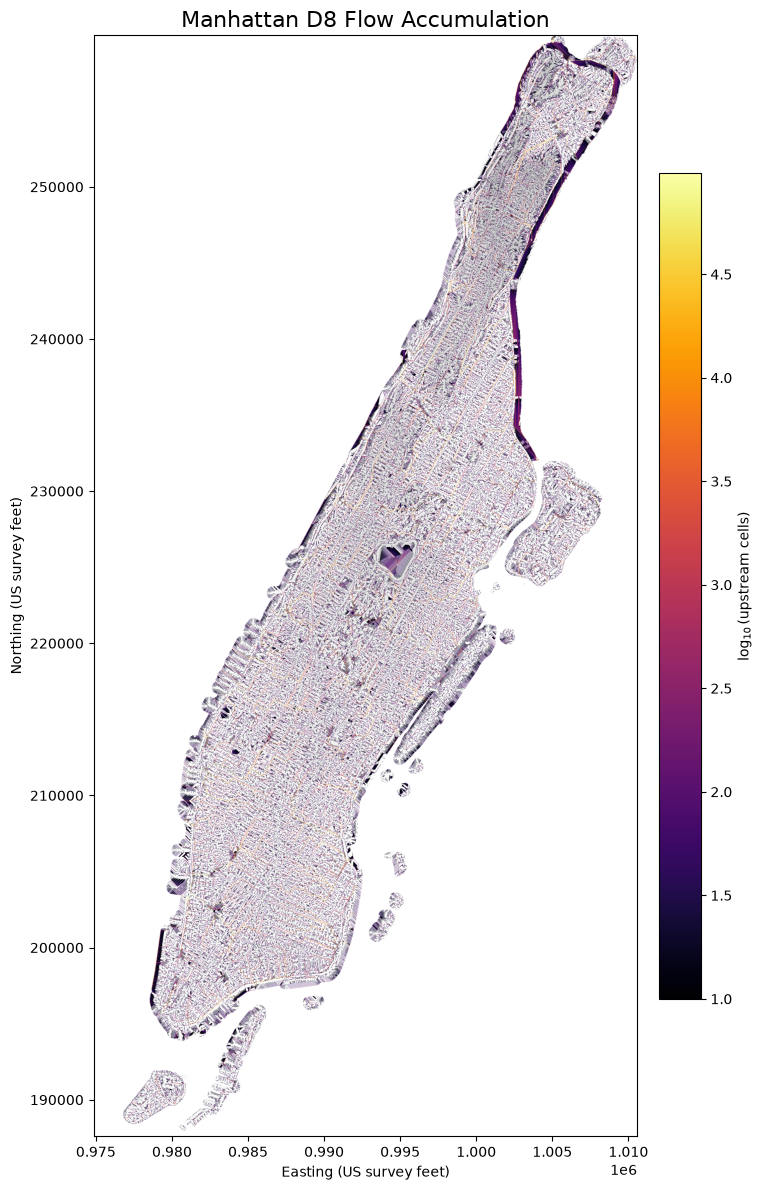

Visualization includes accumulation >= 10 cells.
Display capped near: 97523 upstream cells
Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\outputs\manhattan_d8_flow_accumulation.png


In [15]:
flow_log10 = np.full(
    flow_accumulation_cells.shape,
    np.nan,
    dtype=np.float32,
)

positive_flow = (
    np.isfinite(flow_accumulation_cells)
    & (flow_accumulation_cells > 0)
)

flow_log10[positive_flow] = np.log10(
    flow_accumulation_cells[positive_flow]
).astype(np.float32)


# Hide very small contributing areas only in the visualization.
flow_display_mask = (
    positive_flow
    & (flow_accumulation_cells >= 10)
)

flow_display = np.ma.masked_where(
    ~flow_display_mask,
    flow_log10,
)

flow_display_values = flow_log10[
    flow_display_mask
]

flow_display_max = float(
    np.percentile(
        flow_display_values,
        99.9,
    )
)

flow_cmap = plt.colormaps["inferno"].copy()
flow_cmap.set_bad(alpha=0)


fig, ax = plt.subplots(figsize=(8, 12))

ax.imshow(
    dem,
    cmap="Greys",
    extent=(
        dem_bounds.left,
        dem_bounds.right,
        dem_bounds.bottom,
        dem_bounds.top,
    ),
    origin="upper",
    alpha=0.25,
)

flow_image = ax.imshow(
    flow_display,
    cmap=flow_cmap,
    vmin=1,
    vmax=flow_display_max,
    extent=(
        dem_bounds.left,
        dem_bounds.right,
        dem_bounds.bottom,
        dem_bounds.top,
    ),
    origin="upper",
)

colorbar = fig.colorbar(
    flow_image,
    ax=ax,
    shrink=0.75,
    pad=0.03,
)

colorbar.set_label(
    r"$\log_{10}$(upstream cells)",
)

ax.set_title(
    "Manhattan D8 Flow Accumulation",
    fontsize=16,
)

ax.set_xlabel("Easting (US survey feet)")
ax.set_ylabel("Northing (US survey feet)")
ax.set_aspect("equal")

plt.tight_layout()

flow_figure_path = (
    OUTPUT_DIR
    / "manhattan_d8_flow_accumulation.png"
)

fig.savefig(
    flow_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Visualization includes accumulation >= 10 cells."
)

print(
    "Display capped near:",
    round(10**flow_display_max),
    "upstream cells",
)

print("Saved to:", flow_figure_path)

### Save Hydrologic Terrain Layers

The raw depression-depth and D8 flow-accumulation values are saved as
georeferenced GeoTIFF files.

Logarithmic flow accumulation is not saved as a separate raster because
it is a derived visualization and modeling transformation. Retaining
the original accumulation values preserves the underlying information
and allows alternative transformations to be applied later.

In [16]:
DEPRESSION_PATH = (
    PROCESSED_DIR
    / "manhattan_depression_depth_5m_epsg6539.tif"
)

FLOW_ACCUMULATION_PATH = (
    PROCESSED_DIR
    / "manhattan_d8_flow_accumulation_5m_epsg6539.tif"
)

DERIVED_NODATA = -9999.0


def save_float_raster(
    values,
    output_path,
    metadata_tags,
):
    output_profile = dem_profile.copy()

    output_profile.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=DERIVED_NODATA,
        compress="deflate",
        predictor=3,
        tiled=True,
        BIGTIFF="IF_SAFER",
    )

    output_values = np.where(
        np.isfinite(values),
        values,
        DERIVED_NODATA,
    ).astype(np.float32)

    with rasterio.open(
        output_path,
        "w",
        **output_profile,
    ) as destination:
        destination.write(
            output_values,
            1,
        )

        destination.update_tags(
            **metadata_tags
        )


save_float_raster(
    values=depression_depth_m,
    output_path=DEPRESSION_PATH,
    metadata_tags={
        "terrain_variable": "depression_depth",
        "units": "metres",
        "method": "PySheds pit and depression filling",
        "source_dem": DEM_PATH.name,
    },
)

save_float_raster(
    values=flow_accumulation_cells,
    output_path=FLOW_ACCUMULATION_PATH,
    metadata_tags={
        "terrain_variable": "d8_flow_accumulation",
        "units": "upstream_cells",
        "method": "PySheds D8",
        "source_dem": DEM_PATH.name,
        "pixel_area_m2": round(pixel_area_m2, 4),
    },
)


for output_path in [
    DEPRESSION_PATH,
    FLOW_ACCUMULATION_PATH,
]:
    with rasterio.open(output_path) as check:
        checked_values = check.read(
            1,
            masked=True,
        )

        print("\nFile:", output_path.name)
        print("CRS:", check.crs)
        print("Shape:", checked_values.shape)
        print("Valid pixels:", checked_values.count())
        print("Minimum:", float(checked_values.min()))
        print("Maximum:", float(checked_values.max()))
        print(
            "File size:",
            round(
                output_path.stat().st_size / 1024**2,
                2,
            ),
            "MB",
        )


File: manhattan_depression_depth_5m_epsg6539.tif
CRS: EPSG:6539
Shape: (4412, 2178)
Valid pixels: 2766408
Minimum: 0.0
Maximum: 16.176137924194336
File size: 2.64 MB

File: manhattan_d8_flow_accumulation_5m_epsg6539.tif
CRS: EPSG:6539
Shape: (4412, 2178)
Valid pixels: 2766408
Minimum: 1.0
Maximum: 213621.0
File size: 3.32 MB


### Assign Hydrologic Features to Buildings

Elevation, slope, and depression depth are sampled at an internal
representative point for each building.

D8 flow paths often follow streets, curbs, and other low terrain beside
a building rather than crossing the building footprint itself.
Therefore, flow accumulation is recorded both at the representative
point and as the maximum value within approximately 10 metres of the
building point.

The nearby maximum represents potential exposure to an adjacent surface
drainage pathway. It does not represent water entering the building.

In [17]:
from scipy.ndimage import maximum_filter
FLOW_SEARCH_RADIUS_M = 10

flow_radius_pixels = int(
    np.ceil(
        FLOW_SEARCH_RADIUS_M
        / pixel_width_m
    )
)

flow_filter_size = (
    2 * flow_radius_pixels + 1
)

flow_filter_input = np.where(
    np.isfinite(flow_accumulation_cells),
    flow_accumulation_cells,
    -np.inf,
)

nearby_max_flow = maximum_filter(
    flow_filter_input,
    size=flow_filter_size,
    mode="constant",
    cval=-np.inf,
)

nearby_max_flow[
    ~np.isfinite(nearby_max_flow)
] = np.nan


building_depression_depth_m = np.full(
    len(buildings_terrain),
    np.nan,
    dtype=np.float32,
)

building_flow_at_point = np.full(
    len(buildings_terrain),
    np.nan,
    dtype=np.float64,
)

building_flow_10m_max = np.full(
    len(buildings_terrain),
    np.nan,
    dtype=np.float64,
)


terrain_indices = np.where(
    both_available
)[0]

terrain_rows = sample_rows[
    terrain_indices
]

terrain_columns = sample_columns[
    terrain_indices
]


building_depression_depth_m[
    terrain_indices
] = depression_depth_m[
    terrain_rows,
    terrain_columns,
]

building_flow_at_point[
    terrain_indices
] = flow_accumulation_cells[
    terrain_rows,
    terrain_columns,
]

building_flow_10m_max[
    terrain_indices
] = nearby_max_flow[
    terrain_rows,
    terrain_columns,
]


buildings_terrain[
    "depression_depth_m"
] = building_depression_depth_m

buildings_terrain[
    "flow_accumulation_cells"
] = building_flow_at_point

buildings_terrain[
    "flow_accumulation_10m_max"
] = building_flow_10m_max

buildings_terrain[
    "flow_accumulation_10m_area_m2"
] = (
    building_flow_10m_max
    * pixel_area_m2
)

buildings_terrain[
    "log10_flow_accumulation_10m"
] = np.where(
    building_flow_10m_max > 0,
    np.log10(building_flow_10m_max),
    np.nan,
)


complete_terrain_data = (
    both_available
    & np.isfinite(
        buildings_terrain["depression_depth_m"]
    )
    & np.isfinite(
        buildings_terrain["flow_accumulation_10m_max"]
    )
)

buildings_terrain[
    "terrain_model_eligible"
] = complete_terrain_data


print(
    "Search radius:",
    flow_radius_pixels,
    "pixels",
)

print(
    "Filter size:",
    f"{flow_filter_size} x {flow_filter_size}",
)

print(
    "Buildings with complete terrain data:",
    complete_terrain_data.sum(),
)

print(
    "Complete terrain coverage:",
    f"{complete_terrain_data.mean():.2%}",
)

print(
    "\nBuilding-level hydrologic summary:"
)

display(
    buildings_terrain.loc[
        complete_terrain_data,
        [
            "depression_depth_m",
            "flow_accumulation_cells",
            "flow_accumulation_10m_max",
            "log10_flow_accumulation_10m",
        ],
    ]
    .describe(
        percentiles=[
            0.50,
            0.95,
            0.99,
        ]
    )
    .round(3)
)

Search radius: 2 pixels
Filter size: 5 x 5
Buildings with complete terrain data: 45169
Complete terrain coverage: 99.94%

Building-level hydrologic summary:


,depression_depth_m,flow_accumulation_cells,flow_accumulation_10m_max,log10_flow_accumulation_10m
count,45169.000,45169.000,45169.000,45169.000
mean,0.297,156.420,1180.301,1.935
std,0.574,2711.382,7503.264,0.805
min,0.000,1.000,3.000,0.477
50%,0.000,3.000,64.000,1.806
95%,1.512,151.000,3050.600,3.484
99%,2.232,1411.120,25170.400,4.401
max,15.105,121338.000,212957.000,5.328


### Save Building-Level Terrain Features

The terrain variables are stored with the Manhattan building
footprints in a new GeoPackage.

Buildings without complete DEM coverage remain in the dataset but are
marked as ineligible for terrain-dependent modeling. This preserves the
original building inventory and makes exclusions explicit.

In [18]:
additional_hydrology_missing = (
    both_available
    & ~complete_terrain_data
)

buildings_terrain.loc[
    additional_hydrology_missing,
    "terrain_exclusion_reason",
] = "No valid hydrologic terrain attributes"


BUILDING_TERRAIN_PATH = (
    PROCESSED_DIR
    / "manhattan_buildings_with_terrain.gpkg"
)

buildings_terrain.to_file(
    BUILDING_TERRAIN_PATH,
    layer="buildings_terrain",
    driver="GPKG",
    mode="w",
)


saved_buildings_terrain = gpd.read_file(
    BUILDING_TERRAIN_PATH,
    layer="buildings_terrain",
)

print("Saved to:", BUILDING_TERRAIN_PATH)
print("Rows:", len(saved_buildings_terrain))
print("CRS:", saved_buildings_terrain.crs)

print(
    "\nTerrain eligibility:"
)

print(
    saved_buildings_terrain[
        "terrain_model_eligible"
    ].value_counts(dropna=False)
)

print(
    "\nFile size:",
    round(
        BUILDING_TERRAIN_PATH.stat().st_size
        / 1024**2,
        2,
    ),
    "MB",
)

Saved to: c:\Users\Owner\Desktop\manhattan_flood_risk\manhattan-pluvial-flood-risk\data\processed\manhattan_buildings_with_terrain.gpkg
Rows: 45195
CRS: EPSG:6539

Terrain eligibility:
terrain_model_eligible
True     45169
False       26
Name: count, dtype: int64

File size: 26.11 MB


## Terrain Feature Validation

The final building-level terrain dataset is validated before it is used
in downstream flood-risk modeling.

The checks confirm that:

- all eligible buildings have complete terrain attributes;
- excluded buildings have an explicit exclusion reason;
- slope values remain between 0 and 90 degrees;
- depression depth is non-negative;
- nearby flow accumulation is not smaller than point accumulation;
- upstream area and logarithmic transformations are internally
  consistent;
- building geometries remain valid.

In [19]:
eligible_buildings = buildings_terrain.loc[
    buildings_terrain["terrain_model_eligible"]
].copy()

excluded_buildings = buildings_terrain.loc[
    ~buildings_terrain["terrain_model_eligible"]
].copy()


terrain_feature_columns = [
    "dem_elevation_m",
    "slope_degrees",
    "depression_depth_m",
    "flow_accumulation_cells",
    "flow_accumulation_10m_max",
    "flow_accumulation_10m_area_m2",
    "log10_flow_accumulation_10m",
]


eligible_feature_values = eligible_buildings[
    terrain_feature_columns
].to_numpy(dtype=float)


validation_checks = {
    "At least 99% terrain coverage": (
        buildings_terrain[
            "terrain_model_eligible"
        ].mean()
        >= 0.99
    ),

    "Eligible buildings have complete features": (
        np.isfinite(
            eligible_feature_values
        ).all()
    ),

    "Excluded buildings have a reason": (
        excluded_buildings[
            "terrain_exclusion_reason"
        ]
        .notna()
        .all()
    ),

    "Slope is between 0 and 90 degrees": (
        eligible_buildings[
            "slope_degrees"
        ]
        .between(0, 90)
        .all()
    ),

    "Depression depth is non-negative": (
        (
            eligible_buildings[
                "depression_depth_m"
            ]
            >= 0
        )
        .all()
    ),

    "Nearby flow is at least point flow": (
        (
            eligible_buildings[
                "flow_accumulation_10m_max"
            ]
            >= eligible_buildings[
                "flow_accumulation_cells"
            ]
        )
        .all()
    ),

    "Upstream area conversion is correct": (
        np.allclose(
            eligible_buildings[
                "flow_accumulation_10m_area_m2"
            ],
            eligible_buildings[
                "flow_accumulation_10m_max"
            ]
            * pixel_area_m2,
        )
    ),

    "Log transformation is correct": (
        np.allclose(
            eligible_buildings[
                "log10_flow_accumulation_10m"
            ],
            np.log10(
                eligible_buildings[
                    "flow_accumulation_10m_max"
                ]
            ),
        )
    ),

    "Building geometries are valid": (
        buildings_terrain.geometry.notna().all()
        and buildings_terrain.geometry.is_valid.all()
    ),
}


validation_table = pd.DataFrame(
    {
        "check": list(
            validation_checks.keys()
        ),
        "passed": list(
            validation_checks.values()
        ),
    }
)

validation_table["status"] = np.where(
    validation_table["passed"],
    "PASS",
    "FAIL",
)


display(
    validation_table[
        [
            "check",
            "status",
        ]
    ]
)


if not all(
    validation_checks.values()
):
    failed_checks = [
        check_name
        for check_name, passed
        in validation_checks.items()
        if not passed
    ]

    raise ValueError(
        "Terrain validation failed: "
        + "; ".join(failed_checks)
    )


print("\nAll terrain validation checks passed.")
print("Total buildings:", len(buildings_terrain))
print("Eligible buildings:", len(eligible_buildings))
print("Excluded buildings:", len(excluded_buildings))

print(
    "Coverage:",
    f"{len(eligible_buildings) / len(buildings_terrain):.2%}",
)

,check,status
0,At least 99% terrain coverage,PASS
1,Eligible buildings have complete features,PASS
2,Excluded buildings have a reason,PASS
3,Slope is between 0 and 90 degrees,PASS
4,Depression depth is non-negative,PASS
5,Nearby flow is at least point flow,PASS
6,Upstream area conversion is correct,PASS
7,Log transformation is correct,PASS
8,Building geometries are valid,PASS



All terrain validation checks passed.
Total buildings: 45195
Eligible buildings: 45169
Excluded buildings: 26
Coverage: 99.94%


## Summary

Terrain and hydrologic features were successfully generated for
Manhattan buildings using a 5 m NOAA digital elevation model.

### Outputs

- Terrain elevation in metres relative to NAVD88
- Horn \(3 \times 3\) slope in degrees
- Filled-depression depth in metres
- D8 flow accumulation at each building point
- Maximum D8 flow accumulation within approximately 10 metres
- Log-transformed nearby flow accumulation

### Coverage

- Total Manhattan buildings: **45,195**
- Buildings with complete terrain attributes: **45,169**
- Buildings excluded from terrain-dependent modeling: **26**
- Final terrain coverage: **99.94%**

The excluded buildings remain in the dataset with an explicit exclusion
reason.

### Important Limitations

- D8 represents potential surface-flow routing, not observed flooding.
- The analysis does not include storm-sewer capacity or underground
  drainage infrastructure.
- Filled-depression depth is a terrain indicator and should not be
  interpreted as predicted flood depth.
- The 10 m nearby-flow measure uses a square \(5 \times 5\) raster
  neighborhood rather than an exact circular buffer.
- Extreme terrain values may reflect coastlines, transportation
  infrastructure, water bodies, or remaining DEM artifacts.
- Terrain variables must be combined with rainfall, drainage, exposure,
  and vulnerability variables before estimating building-level flood
  risk.